# 02 — Compute Indices and Build ML Dataset
This notebook loads the datacube produced in notebook 01, computes:
- **CHL** — Gons/Ruddick NIR-red chlorophyll-a
- **MALH** — Modified Astoreca Line Height (P. globosa index, Lavigne 2022)
- **D2rhow** — Second derivative of normalised reflectance (Lubac 2008)
- **P_LUB** — Lubac classification label (1 = P. globosa, 0 = absence)

Then applies quality control and saves one row per day.


In [1]:
import sys
from phytospec import config as cfg
from phytospec import load_datacube, make_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.dates as mdates
from matplotlib.lines import Line2D


In [2]:
STATION = "RT1"
YEAR    = 2024

cube_path    = cfg.DATA_PROCESSED / f"datacube_{STATION}_{YEAR}.npz"
dataset_path = cfg.DATA_PROCESSED / f"REFERENCE_DATASET_4_WP2_{STATION}_{YEAR}.csv"


## Load datacube

In [3]:
datacube = load_datacube(cube_path)


[io] Datacube loaded ← C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\datacube_RT1_2024.npz  (2503 spectra)


## Compute indices and build dataset

In [4]:
dataset = make_dataset(
    datacube    = datacube,
    one_per_day = True,
    noon_max_offset_hours=3.0, #noon_max_offset_hours=None to disable or keep everything
    save_path   = dataset_path,
)

dataset.head(5)


[dataset] Computing spectral indices for 2503 spectra ...

[qc] Dataset QC
     nir_sza_removed          : 159
     low_chl_removed          : 0
     apply_chl_qc             : False
     total_input              : 2503
     total_kept               : 2344
[dataset] QC removed 159 spectra, 2344 retained.
[dataset] Final dataset: 168 days x 478 columns
          CHL valid (>0): 109 / 168 days
          P. globosa days (P_LUB=1): 34
[dataset] Saved -> C:\Users\gvillegas\OneDrive - Institute of Natural Sciences\Projects\REMSEM\aquatime\AQUAPHYTO\data\processed\REFERENCE_DATASET_4_WP2_RT1_2024.csv


,date,CHL,MALH,P_LUB,rhow_355.0,rhow_357.5,rhow_360.0,rhow_362.5,rhow_365.0,rhow_367.5,...,D2rhow_922.5,D2rhow_925.0,D2rhow_927.5,D2rhow_930.0,D2rhow_932.5,D2rhow_935.0,D2rhow_937.5,D2rhow_940.0,D2rhow_942.5,D2rhow_945.0
0,2024-01-03,NaN,-0.003317,1,0.012544,0.012852,0.013246,0.013483,0.013926,0.014257,...,0.000328,0.000411,0.000300,0.000079,-1.085448e-04,-0.000241,-0.000271,-0.000011,NaN,NaN
1,2024-01-04,NaN,-0.001866,1,0.017425,0.017632,0.017935,0.018029,0.018365,0.018559,...,0.000175,0.000255,0.000168,-0.000051,-1.274263e-04,-0.000196,-0.000188,0.000118,NaN,NaN
2,2024-01-19,NaN,-0.002240,1,0.032162,0.032729,0.033466,0.033754,0.034526,0.035059,...,0.000077,0.000094,0.000046,-0.000046,-6.965288e-07,-0.000038,-0.000002,0.000120,NaN,NaN
3,2024-01-20,NaN,-0.002796,1,0.031980,0.032605,0.033413,0.033775,0.034612,0.035197,...,0.000062,0.000079,0.000077,0.000046,1.115335e-05,0.000006,0.000061,0.000170,NaN,NaN
4,2024-01-29,NaN,-0.002603,0,0.013718,0.013837,0.014045,0.014108,0.014359,0.014520,...,0.000102,0.000205,0.000134,-0.000115,-4.333698e-05,-0.000112,-0.000187,-0.000027,NaN,NaN


## Summary statistics

In [5]:
print(f"Shape: {dataset.shape}")
print(f"\nKey columns summary:")
dataset[['date','CHL','MALH','P_LUB']].describe()


Shape: (168, 478)

Key columns summary:


,CHL,MALH,P_LUB
count,109.000000,168.000000,168.000000
mean,13.052972,-0.003270,0.202381
std,6.679653,0.002544,0.402976
min,2.733385,-0.008693,0.000000
25%,8.447869,-0.004624,0.000000
50%,11.510823,-0.003445,0.000000
75%,17.272203,-0.002255,0.000000
max,34.072379,0.011231,1.000000


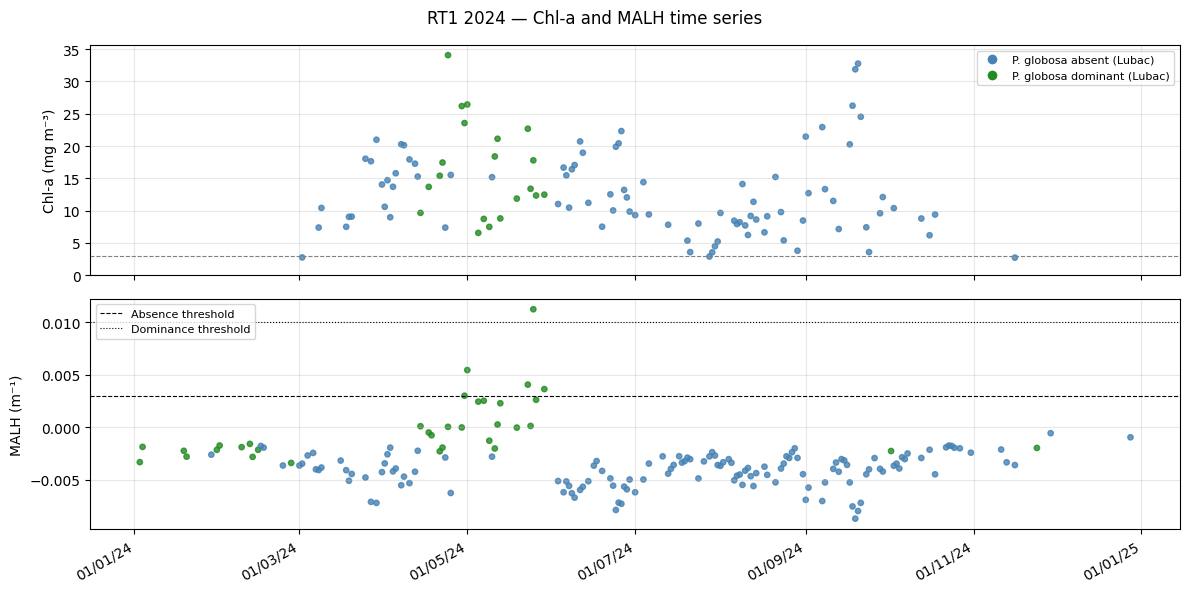

In [6]:


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

dates = pd.to_datetime(dataset['date'])
colors = dataset['P_LUB'].map({0: 'steelblue', 1: 'forestgreen'})

ax1.scatter(dates, dataset['CHL'], c=colors, s=15, alpha=0.8)
ax1.set(ylabel='Chl-a (mg m⁻³)', ylim=(0, None))
ax1.axhline(cfg.QC_CHL_MIN, color='grey', linestyle='--', lw=0.8)
ax1.grid(alpha=0.3)

ax2.scatter(dates, dataset['MALH'], c=colors, s=15, alpha=0.8)
ax2.axhline(0.003, color='k', linestyle='--', lw=0.8, label='Absence threshold')
ax2.axhline(0.010, color='k', linestyle=':',  lw=0.8, label='Dominance threshold')
ax2.set(ylabel='MALH (m⁻¹)')
ax2.legend(loc='upper left', fontsize=8)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
fig.autofmt_xdate()

from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
                          markersize=8, label='P. globosa absent (Lubac)'),
                   Line2D([0],[0], marker='o', color='w', markerfacecolor='forestgreen',
                          markersize=8, label='P. globosa dominant (Lubac)')]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=8)
fig.suptitle(f'{STATION} {YEAR} — Chl-a and MALH time series', fontsize=12)
plt.tight_layout()
plt.show()


## Figure — Reflectance and second derivative spectra
Reproduces the three panels from the manuscript (Fig. 2):
1. Raw water reflectance spectra (400–800 nm)
2. Reflectance normalised by ρw(620 nm) — zoom 440–520 nm
3. Second derivative of normalised reflectance — zoom 440–520 nm

Blue = diatom bloom period · Green = *P. globosa* bloom period

## Spectral figures — reflectance and second derivative
Three panels (400–800 nm overview, 440–520 nm normalised, 440–520 nm second derivative).
Blue = diatom bloom · Green = *P. globosa* bloom

Diatom spectra  : 6 days
P. globosa spectra: 7 days


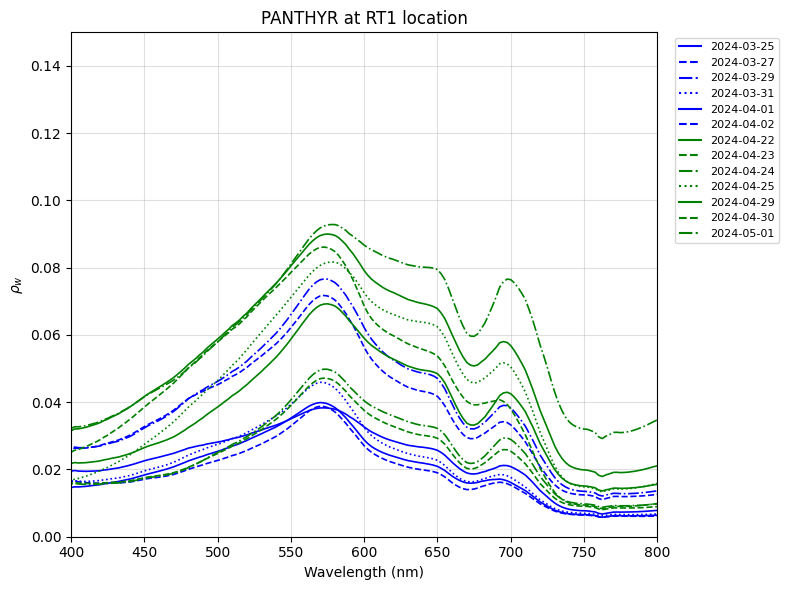

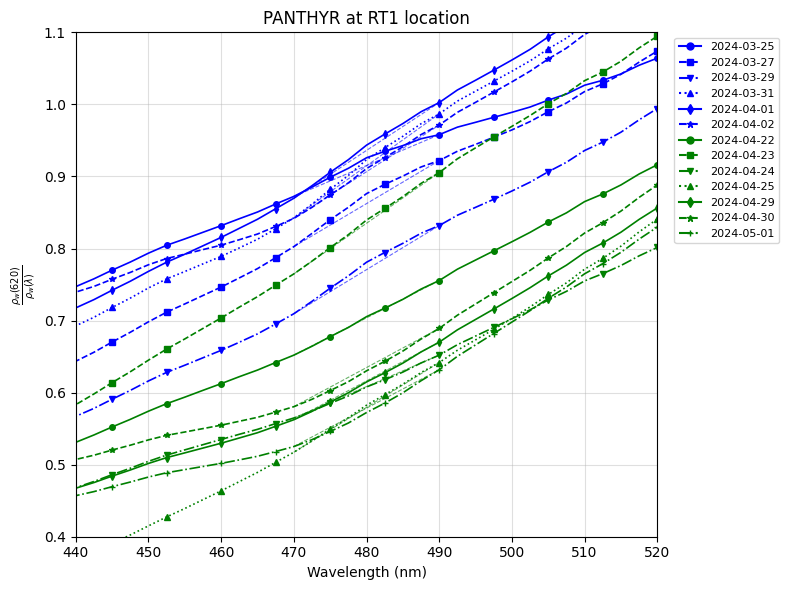

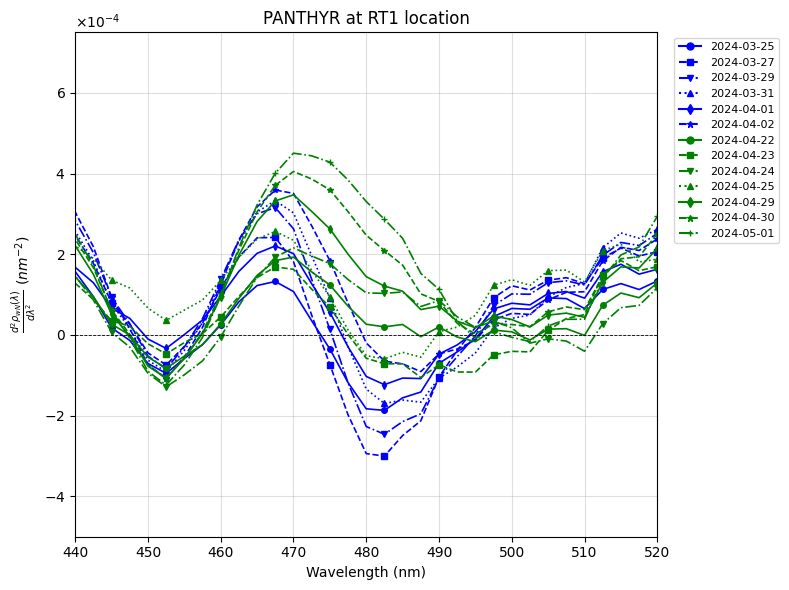

In [8]:
# ── Configure date ranges (edit to match your bloom periods) ──────────────────
DIATOM_START  = "2024-03-25"
DIATOM_END    = "2024-04-02"
PHAEO_START   = "2024-04-22"
PHAEO_END     = "2024-05-01"

# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv(dataset_path, parse_dates=["date"])

# extract wavelength grid from column names
rhow_cols  = [c for c in df.columns if c.startswith("rhow_") and not c.startswith("D2")]
d2row_cols = [c for c in df.columns if c.startswith("D2rhow_")]
wl = np.array([float(c.split("_")[1]) for c in rhow_cols])

# ── Select diatom and P. globosa periods ──────────────────────────────────────
diatoms = df[(df["date"] >= DIATOM_START) & (df["date"] <= DIATOM_END)].copy()
phaeo   = df[(df["date"] >= PHAEO_START)  & (df["date"] <= PHAEO_END)].copy()

print(f"Diatom spectra  : {len(diatoms)} days")
print(f"P. globosa spectra: {len(phaeo)} days")

# ── Style helpers ──────────────────────────────────────────────────────────────
line_styles = ["-", "--", "-.", ":", "-", "--", "-.", ":", "-", "--", "-.", ":"]
markers     = ["o", "s", "v", "^", "d", "*", "+", "x", "D", "p", "h", "1"]

def plot_group(ax, data, rhow_cols, wl, color, line_styles, markers,
               xlim, ylim, use_markers=False, norm620=False, plot_baseline=False):
    idx_620 = int(np.argmin(np.abs(wl - 620.0)))
    for i, (_, row) in enumerate(data.iterrows()):
        rhow = row[rhow_cols].values.astype(float)
        label = str(row["date"])[:10]
        ls = line_styles[i % len(line_styles)]
        mk = markers[i % len(markers)] if use_markers else None

        if norm620:
            rhow = rhow / rhow[idx_620]

        kwargs = dict(color=color, linestyle=ls, label=label, linewidth=1.2)
        if mk:
            kwargs["marker"] = mk
            kwargs["markersize"] = 4
            kwargs["markevery"] = 3

        ax.plot(wl, rhow, **kwargs)

        if plot_baseline and norm620:
            y470 = float(np.interp(470, wl, rhow))
            y490 = float(np.interp(490, wl, rhow))
            ax.plot([470, 490], [y470, y490], "--", color=color, linewidth=0.8, alpha=0.6)

# ── Figure 1: Raw reflectance 400–800 nm ──────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 6))
plot_group(ax1, diatoms, rhow_cols, wl, "blue",  line_styles, markers,
           xlim=(400, 800), ylim=(0, 0.15))
plot_group(ax1, phaeo,   rhow_cols, wl, "green", line_styles, markers,
           xlim=(400, 800), ylim=(0, 0.15))

ax1.set_xlim([400, 800])
ax1.set_ylim([0, 0.15])
ax1.set_xlabel("Wavelength (nm)")
ax1.set_ylabel(r"$\rho_{w}$")
ax1.set_title("PANTHYR at RT1 location")
ax1.grid(alpha=0.4)

# combined legend
handles1, labels1 = [], []
for i, (_, row) in enumerate(diatoms.iterrows()):
    
    handles1.append(Line2D([0],[0], color="blue",  linestyle=line_styles[i%12], label=str(row["date"])[:10]))
for i, (_, row) in enumerate(phaeo.iterrows()):
    handles1.append(Line2D([0],[0], color="green", linestyle=line_styles[i%12], label=str(row["date"])[:10]))
ax1.legend(handles=handles1, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"PANTHYR_reflectance_spectra_{STATION}_{YEAR}.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure 2: Normalised reflectance 440–520 nm ───────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 6))
plot_group(ax2, diatoms, rhow_cols, wl, "blue",  line_styles, markers,
           xlim=(440, 520), ylim=(0.4, 1.1),
           use_markers=True, norm620=True, plot_baseline=True)
plot_group(ax2, phaeo,   rhow_cols, wl, "green", line_styles, markers,
           xlim=(440, 520), ylim=(0.4, 1.1),
           use_markers=True, norm620=True, plot_baseline=True)

ax2.set_xlim([440, 520])
ax2.set_ylim([0.4, 1.1])
ax2.set_xlabel("Wavelength (nm)")
ax2.set_ylabel(r"$\frac{\rho_{w}(620)}{\rho_{w}(\lambda)}$")
ax2.set_title("PANTHYR at RT1 location")
ax2.grid(alpha=0.4)

handles2 = []
for i, (_, row) in enumerate(diatoms.iterrows()):
    from matplotlib.lines import Line2D
    handles2.append(Line2D([0],[0], color="blue",  marker=markers[i%9],
                           linestyle=line_styles[i%12], label=str(row["date"])[:10], markersize=5))
for i, (_, row) in enumerate(phaeo.iterrows()):
    handles2.append(Line2D([0],[0], color="green", marker=markers[i%9],
                           linestyle=line_styles[i%12], label=str(row["date"])[:10], markersize=5))
ax2.legend(handles=handles2, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"PANTHYR_normalized_reflectance_spectra_{STATION}_{YEAR}.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Figure 3: Second derivative 440–520 nm ────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(8, 6))

for i, (_, row) in enumerate(diatoms.iterrows()):
    d2 = row[d2row_cols].values.astype(float)
    mk = markers[i % len(markers)]
    ax3.plot(wl, d2, color="blue", linestyle=line_styles[i%12],
             marker=mk, markersize=4, markevery=3,
             label=str(row["date"])[:10], linewidth=1.2)

for i, (_, row) in enumerate(phaeo.iterrows()):
    d2 = row[d2row_cols].values.astype(float)
    mk = markers[i % len(markers)]
    ax3.plot(wl, d2, color="green", linestyle=line_styles[i%12],
             marker=mk, markersize=4, markevery=3,
             label=str(row["date"])[:10], linewidth=1.2)

ax3.axhline(0, color="k", linewidth=0.6, linestyle="--")
ax3.set_xlim([440, 520])
ax3.set_ylim([-0.0005, 0.00075])
ax3.set_xlabel("Wavelength (nm)")
ax3.set_ylabel(r"$\frac{d^2\rho_{wN}(\lambda)}{d\lambda^2}$ $(nm^{-2})$")
ax3.set_title("PANTHYR at RT1 location")
ax3.grid(alpha=0.4)
ax3.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax3.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

handles3 = []
for i, (_, row) in enumerate(diatoms.iterrows()):
    from matplotlib.lines import Line2D
    handles3.append(Line2D([0],[0], color="blue",  marker=markers[i%9],
                           linestyle=line_styles[i%12], label=str(row["date"])[:10], markersize=5))
for i, (_, row) in enumerate(phaeo.iterrows()):
    handles3.append(Line2D([0],[0], color="green", marker=markers[i%9],
                           linestyle=line_styles[i%12], label=str(row["date"])[:10], markersize=5))
ax3.legend(handles=handles3, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"PANTHYR_second_derivative_spectra_{STATION}_{YEAR}.png", dpi=300, bbox_inches="tight")
plt.show()
